In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import clone_model

In [3]:
night_dfs = [night1, night2, night3, night4, night5, night6, night7, night8, night9, night10, night11, night12, night13, night14, night15, night16, night17, night18, night19, night20, night21, night22, night23,night24, night25, night26,night27,night28,night29,night30,night31,night32, night33,night34,night35,night36,night37,night38,night39,night40,night41,night42,night43,night44,night45]

In [ ]:
# ------------------------- Step 1: Assign Demographic Data -------------------------
# Demographic details for individuals
heights = [None] * 4  # Participant demographics removed for confidentiality
weights = [None] * 4
ages = [None] * 4
genders = [None] * 4

# Assigning individuals to their nights
person1_df = [night1, night2, night3, night4, night5, night6, night7, night8, night9, night10, night11, night12, night13, night14]
person2_df = [night15, night16, night17, night18, night19, night20, night21, night22, night23]
person3_df = [night24, night25, night26, night27, night28, night29, night30, night31, night32, night33, night34, night35, night36, night37]
person4_df = [night38, night39, night40, night41, night42, night43, night44, night45]

# Function to assign demographic data
def add_demographics(df_list, height, weight, age, gender):
    gender_binary = 1 if gender == 'Male' else 0  # Convert gender to binary
    for df in df_list:
        df['Height'] = height
        df['Weight'] = weight
        df['Age'] = age
        df['Gender'] = gender_binary

# Assign demographics to each individual's nights
add_demographics(person1_df, heights[0], weights[0], ages[0], genders[0])
add_demographics(person2_df, heights[1], weights[1], ages[1], genders[1])
add_demographics(person3_df, heights[2], weights[2], ages[2], genders[2])
add_demographics(person4_df, heights[3], weights[3], ages[3], genders[3])

In [5]:
# ------------------------- Step 2: Prepare HRV Data & Sequences -------------------------
# Function to create sequences for LSTM
def create_sequences(data, timesteps=18):
    X, y = [], []
    for i in range(len(data) - timesteps):
        X.append(data[i:i + timesteps, :-1])  # HRV features
        y.append(data[i + timesteps, -1])  # Glucose value
    return np.array(X), np.array(y)

# Split nights into train and test sets
train_nights = [night for i, night in enumerate(night_dfs) if i not in [5, 10, 15, 20, 25, 30, 35, 40, 45]]
test_nights = [night for i, night in enumerate(night_dfs) if i in [5, 10, 15, 20, 25, 30, 35, 40, 45]]

# Prepare LSTM and RF training data
X_all, y_all, demo_features = [], [], []

for night_df in train_nights:
    # Extract HRV and glucose data
    data = night_df[['rmssd', 'lf', 'hf', 'Infrared to Red Signal Ratio', 'glucose']].values
    X_night, y_night = create_sequences(data, timesteps=18)

    # Extract demographic data (same for all rows in a night)
    demo_night = night_df[['Height', 'Weight', 'Age', 'Gender']].iloc[0].values  

    # Append data
    X_all.append(X_night)
    y_all.append(y_night)
    demo_features.append(np.tile(demo_night, (X_night.shape[0], 1)))  # Repeat demo data to match sequence count

# Combine all sequences
X_combined = np.concatenate(X_all, axis=0)
y_combined = np.concatenate(y_all, axis=0)
demo_combined = np.concatenate(demo_features, axis=0)

# Scale HRV and demographic data
scaler = StandardScaler()
n_samples, timesteps, n_features = X_combined.shape
X_reshaped = X_combined.reshape(-1, n_features)
X_scaled = scaler.fit_transform(X_reshaped).reshape(n_samples, timesteps, n_features)

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y_combined.reshape(-1, 1)).flatten()

demo_scaler = StandardScaler()
demo_scaled = demo_scaler.fit_transform(demo_combined)

# Split data into train and test sets
X_train, X_test, y_train, y_test, demo_train, demo_test = train_test_split(
    X_scaled, y_scaled, demo_scaled, test_size=0.2, random_state=42
)

In [6]:
# ------------------------- Step 3: Train GRU Model -------------------------
def create_gru_model(input_timesteps=18, input_features=4):
    model = Sequential([
        GRU(64, input_shape=(input_timesteps, input_features), return_sequences=False),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(1, activation='linear')
    ])
    model.compile(loss="mse", optimizer="adam")
    return model
gru_model = create_gru_model(input_timesteps=18, input_features=4)
# Train model
history = gru_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=8, shuffle=True)

# Extract training & validation metrics
train_loss_per_epoch = history.history['loss']
val_loss_per_epoch = history.history['val_loss']


# Print loss & RMSE for each epoch
for epoch, (train_loss, val_loss) in enumerate(zip(train_loss_per_epoch, val_loss_per_epoch)):
    print(f'Epoch {epoch + 1}: Training Loss = {train_loss:.4f}, Validation Loss = {val_loss:.4f}')


Epoch 1/100


/Users/tomliu/Library/Python/3.11/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.9583 - val_loss: 0.9233
Epoch 2/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8671 - val_loss: 0.8765
Epoch 3/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8642 - val_loss: 0.8918
Epoch 4/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9063 - val_loss: 0.8189
Epoch 5/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.7650 - val_loss: 0.7717
Epoch 6/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6861 - val_loss: 0.8064
Epoch 7/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6563 - val_loss: 0.7232
Epoch 8/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6391 - val_loss: 0.7098
Epoch 9/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5924 - val_loss: 0.6877
Epoch 10/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6029 - val_loss: 0.6523
Epoch 11/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6187 - val_loss: 0.6960
Epoch 12/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

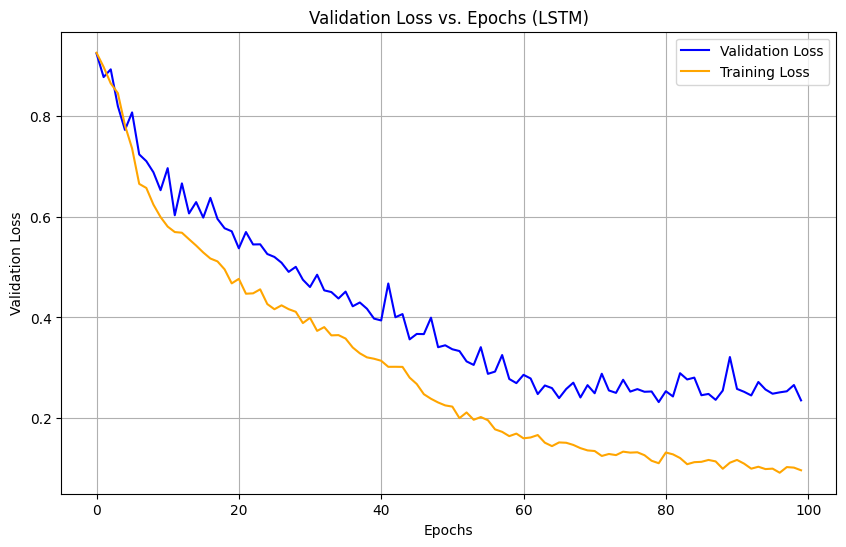

In [7]:

# Step 5: Plot Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.plot(history.history['loss'], label='Training Loss', color='orange')

plt.title('Validation Loss vs. Epochs (LSTM)')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [8]:
# ------------------------- Step 4: Train Random Forest Model -------------------------
# Flatten HRV sequences & combine with demographic data
X_rf_train = np.hstack((X_train.reshape(X_train.shape[0], -1), demo_train))
X_rf_test = np.hstack((X_test.reshape(X_test.shape[0], -1), demo_test))

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_rf_train, y_train)

RandomForestRegressor(random_state=42)

In [9]:
# ------------------------- Step 5: Train Ridge Regression (Ensemble) -------------------------
# LSTM Predictions
gru_test_predictions = gru_model.predict(X_test).flatten()

# Random Forest Predictions
rf_test_predictions = rf_model.predict(X_rf_test)

# Train Ridge regression using both model predictions
ridge_X_train = np.column_stack((gru_test_predictions, rf_test_predictions))
ridge_y_train = y_test

ridge = Ridge(alpha=1.0)
ridge.fit(ridge_X_train, ridge_y_train)

# Ridge Model Predictions
ridge_predictions = ridge.predict(ridge_X_train)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [17]:
import time
sample_input = np.random.rand(8, 2)  # 8 samples, 8 features each

# Measure inference time for Ridge Regression
start_time = time.time()
predictions = ridge.predict(sample_input)
total_inference_time = time.time() - start_time  # Total time in seconds

# Calculate time per sample (in milliseconds)
time_per_sample = (total_inference_time / sample_input.shape[0]) * 1000  # Convert to milliseconds

print(f"Total Inference Time: {total_inference_time:.6f} seconds")
print(f"Time Per Sample: {time_per_sample:.6f} ms")

Total Inference Time: 0.015711 seconds
Time Per Sample: 1.963854 ms


In [10]:
# Function to evaluate models with inverse-transformed predictions
def evaluate_model(name, y_true, y_pred, scaler):
    # Inverse transform predictions and actual values
    y_true_orig = scaler.inverse_transform(y_true.reshape(-1, 1)).flatten()
    y_pred_orig = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

    # Calculate metrics
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    mse = mean_squared_error(y_true_orig, y_pred_orig)
    rmse=root_mean_squared_error(y_true_orig, y_pred_orig)
    r2 = r2_score(y_true_orig, y_pred_orig)

    print(f"\n{name} Model Performance (Original Scale):")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

y_test_orig = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Inverse transform predictions
lstm_test_predictions_orig = y_scaler.inverse_transform(gru_test_predictions.reshape(-1, 1)).flatten()
rf_test_predictions_orig = y_scaler.inverse_transform(rf_test_predictions.reshape(-1, 1)).flatten()
ridge_predictions_orig = y_scaler.inverse_transform(ridge_predictions.reshape(-1, 1)).flatten()

# Evaluate models with inverse-transformed values
evaluate_model("LSTM", y_test, gru_test_predictions, y_scaler)
evaluate_model("Random Forest", y_test, rf_test_predictions, y_scaler)
evaluate_model("Ridge Regression (Ensemble)", y_test, ridge_predictions, y_scaler)





LSTM Model Performance (Original Scale):
Mean Absolute Error (MAE): 0.2371
Mean Squared Error (MSE): 0.1170
Root Mean Squared Error (RMSE): 0.3420
R² Score: 0.7607

Random Forest Model Performance (Original Scale):
Mean Absolute Error (MAE): 0.4288
Mean Squared Error (MSE): 0.3578
Root Mean Squared Error (RMSE): 0.5981
R² Score: 0.2679

Ridge Regression (Ensemble) Model Performance (Original Scale):
Mean Absolute Error (MAE): 0.2283
Mean Squared Error (MSE): 0.1135
Root Mean Squared Error (RMSE): 0.3368
R² Score: 0.7679

Ensemble Model Contributions (Ridge Regression Coefficients):
GRU Contribution: 99.12%
Random Forest Contribution: 0.88%


In [ ]:
# ------------------------- Step 7: Analyze Ensemble Model Contributions -------------------------

# Get Ridge regression coefficients (importance of each model in the ensemble)
ridge_coefficients = ridge.coef_

# Normalize the coefficients to sum to 1 (relative importance)
ridge_importance = np.abs(ridge_coefficients) / np.sum(np.abs(ridge_coefficients))

# Print importance of each model
print("\nEnsemble Model Contributions (Ridge Regression Coefficients):")
print(f"GRU Contribution: {ridge_importance[0] * 100:.2f}%")
print(f"Random Forest Contribution: {ridge_importance[1] * 100:.2f}%")


In [ ]:


# Define number of splits for cross-validation
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# Store results
gru_errors, rf_errors, ridge_errors = [], [], []

for train_idx, val_idx in tscv.split(X_scaled):
    print(f"Processing fold...")

    # Split train and validation data
    X_train_fold, X_val_fold = X_scaled[train_idx], X_scaled[val_idx]
    y_train_fold, y_val_fold = y_scaled[train_idx], y_scaled[val_idx]
    demo_train_fold, demo_val_fold = demo_scaled[train_idx], demo_scaled[val_idx]

    # Flatten HRV sequences for RF
    X_rf_train = np.hstack((X_train_fold.reshape(X_train_fold.shape[0], -1), demo_train_fold))
    X_rf_val = np.hstack((X_val_fold.reshape(X_val_fold.shape[0], -1), demo_val_fold))

    # Clone and train GRU model
    gru_model_fold = clone_model(gru_model)
    gru_model_fold.compile(loss="mse", optimizer="adam")
    gru_model_fold.fit(X_train_fold, y_train_fold, epochs=100, batch_size=8, verbose=0, shuffle=True)

    # Predict with GRU
    gru_val_predictions = gru_model_fold.predict(X_val_fold).flatten()

    # Train and predict with Random Forest
    rf_model_fold = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model_fold.fit(X_rf_train, y_train_fold)
    rf_val_predictions = rf_model_fold.predict(X_rf_val)

    # Stack predictions for Ridge Regression
    ridge_X_train = np.column_stack((gru_val_predictions, rf_val_predictions))
    ridge = Ridge(alpha=1.0)
    ridge.fit(ridge_X_train, y_val_fold)

    # Ridge final predictions
    ridge_predictions = ridge.predict(ridge_X_train)

    # Evaluate models
    for name, y_pred, errors in [("GRU", gru_val_predictions, gru_errors),
                                 ("RF", rf_val_predictions, rf_errors),
                                 ("Ridge", ridge_predictions, ridge_errors)]:
        mae = mean_absolute_error(y_val_fold, y_pred)
        mse = mean_squared_error(y_val_fold, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_val_fold, y_pred)
        errors.append((mae, mse, rmse, r2))
        print(f"{name} - MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# Compute average performance across folds
def print_avg_performance(name, errors):
    avg_mae, avg_mse, avg_rmse, avg_r2 = np.mean(errors, axis=0)
    print(f"\n{name} Model Average Performance:")
    print(f"MAE: {avg_mae:.4f}, RMSE: {avg_rmse:.4f}, R²: {avg_r2:.4f}")

print_avg_performance("GRU", gru_errors)
print_avg_performance("Random Forest", rf_errors)
print_avg_performance("Ensemble Ridge", ridge_errors)


(<module 'matplotlib.pyplot' from '/Users/tomliu/Library/Python/3.11/lib/python/site-packages/matplotlib/pyplot.py'>,
 [522, 3, 0, 3, 0])

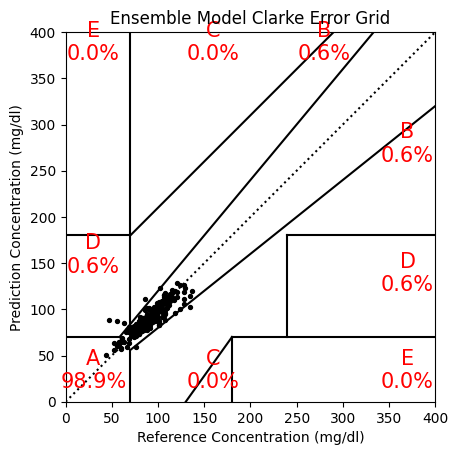

In [12]:

def clarke_error_grid(ref_values, pred_values, title_string):
    ref_values = np.array(ref_values) * 18
    pred_values = np.array(pred_values) * 18
    total_points = len(ref_values)  # Total number of points

    # Set up plot
    plt.scatter(ref_values, pred_values, marker='o', color='black', s=8)
    plt.title(title_string + " Clarke Error Grid")
    plt.xlabel("Reference Concentration (mg/dl)")
    plt.ylabel("Prediction Concentration (mg/dl)")
    plt.xticks([0, 50, 100, 150, 200, 250, 300, 350, 400])
    plt.yticks([0, 50, 100, 150, 200, 250, 300, 350, 400])
    plt.gca().set_facecolor('white')

    # Set axes lengths
    plt.gca().set_xlim([0, 400])
    plt.gca().set_ylim([0, 400])
    plt.gca().set_aspect((400)/(400))

    # Plot zone lines
    plt.plot([0, 400], [0, 400], ':', c='black')                      # Theoretical 45 regression line
    plt.plot([0, 175/3], [70, 70], '-', c='black')
    plt.plot([175/3, 400/1.2], [70, 400], '-', c='black')           
    plt.plot([70, 70], [84, 400],'-', c='black')
    plt.plot([0, 70], [180, 180], '-', c='black')
    plt.plot([70, 290], [180, 400], '-', c='black')
    plt.plot([70, 70], [0, 56], '-', c='black')                    
    plt.plot([70, 400], [56, 320],'-', c='black')
    plt.plot([180, 180], [0, 70], '-', c='black')
    plt.plot([180, 400], [70, 70], '-', c='black')
    plt.plot([240, 240], [70, 180],'-', c='black')
    plt.plot([240, 400], [180, 180], '-', c='black')
    plt.plot([130, 180], [0, 70], '-', c='black')

    # Statistics from the data
    zone = [0] * 5  # [A, B, C, D, E]
    for i in range(len(ref_values)):
        if (ref_values[i] <= 70 and pred_values[i] <= 70) or (pred_values[i] <= 1.2 * ref_values[i] and pred_values[i] >= 0.8 * ref_values[i]):
            zone[0] += 1  # Zone A

        elif (ref_values[i] >= 180 and pred_values[i] <= 70) or (ref_values[i] <= 70 and pred_values[i] >= 180):
            zone[4] += 1  # Zone E

        elif ((ref_values[i] >= 70 and ref_values[i] <= 290) and pred_values[i] >= ref_values[i] + 110) or ((ref_values[i] >= 130 and ref_values[i] <= 180) and (pred_values[i] <= (7/5) * ref_values[i] - 182)):
            zone[2] += 1  # Zone C

        elif (ref_values[i] >= 240 and (pred_values[i] >= 70 and pred_values[i] <= 180)) or (ref_values[i] <= 175/3 and pred_values[i] <= 180 and pred_values[i] >= 70) or ((ref_values[i] >= 175/3 and ref_values[i] <= 70) and pred_values[i] >= (6/5) * ref_values[i]):
            zone[3] += 1  # Zone D

        else:
            zone[1] += 1  # Zone B

    # Convert counts to percentages
    zone_percentages = [100 * (z / total_points) for z in zone]

    # Add zone labels with percentage in red
    plt.text(30, 15, f"A\n{zone_percentages[0]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(370, 260, f"B\n{zone_percentages[1]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(280, 370, f"B\n{zone_percentages[1]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(160, 370, f"C\n{zone_percentages[2]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(160, 15, f"C\n{zone_percentages[2]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(30, 140, f"D\n{zone_percentages[3]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(370, 120, f"D\n{zone_percentages[3]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(30, 370, f"E\n{zone_percentages[4]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(370, 15, f"E\n{zone_percentages[4]:.1f}%", fontsize=15, color='red', ha='center')

    return plt, zone

# Example usage
clarke_error_grid(y_test_orig, ridge_predictions_orig, "Ensemble Model")
